In [1]:
import sys, os
from pathlib import Path
from joblib import Parallel, delayed

THERMOIFT_SRC = Path("../thermoift/src").resolve()
if str(THERMOIFT_SRC) not in sys.path:
    sys.path.insert(0, str(THERMOIFT_SRC))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from thermoift import PLOT_SETTINGS as ps
from matplotlib.ticker import FuncFormatter

N_JOBS = os.cpu_count()
print(f"Using {N_JOBS} CPUs")

combined_df = pd.read_csv("interfacial_results_dataset_A4.csv")
print(f"Loaded {len(combined_df)} rows")

Using 24 CPUs
Loaded 19361 rows


In [2]:
# ── sizing constants ──────────────────────────────────────────────────────
CELL_SIZE     = 0.85
ANNOT_PT      = 18
TICK_PT       = 22
LABEL_PT      = 26
CBAR_FRACTION = 0.03
CBAR_SHRINK   = 1

_math_fmt = FuncFormatter(lambda x, _: rf"${x:.2f}$")

# ── label map ────────────────────────────────────────────────────────────
comp_tex = {
    "carbon dioxide":   r"\mathrm{CO_2}",
    "hydrogen":         r"\mathrm{H_2}",
    "argon":            r"\mathrm{Ar}",
    "nitrogen":         r"\mathrm{N_2}",
    "methane":          r"\mathrm{CH_4}",
    "oxygen":           r"\mathrm{O_2}",
    "carbon monoxide":  r"\mathrm{CO}",
    "hydrogen sulfide": r"\mathrm{H_2S}",
}

label_map = {
    "temperature":           r"$\mathit{T}$",
    "pressure":              r"$\mathit{P}$",
    "P_bubble":              r"$P_{\mathrm{bubble}}$",
    "P_dew":                 r"$P_{\mathrm{dew}}$",
    "liquid_density":        r"$\rho_{\mathrm{L}}$",
    "vapor_density":         r"$\rho_{\mathrm{V}}$",
    "Tc":                    r"$T_{\mathrm{c}}$",
    "Pc":                    r"$P_{\mathrm{c}}$",
    "gamma0_CO2":            r"$\gamma^{0}_{\mathrm{CO_2}}$",
    "rhoL0_CO2":             r"$\rho^{0}_{\mathrm{L,CO_2}}$",
    "rhoV0_CO2":             r"$\rho^{0}_{\mathrm{V,CO_2}}$",
    "gamma":                 r"$\gamma$",
    "interfacial_thickness": r"$L^{90}_{10}$",
}
for comp, tex in comp_tex.items():
    label_map[f"z_{comp}"] = rf"$z_{{{tex}}}$"

In [3]:
# ── features (x-axis): raw inputs + intermediate thermodynamic outputs ────
#   T, P, z_i  →  [PC-SAFT VLE]  →  ρ_L, ρ_V, Tc, Pc, ref-props  →  [cDFT]  →  targets
z_cols = [c for c in combined_df.columns
          if c.startswith("z_") and combined_df[c].nunique() > 1]

all_features = (
    ["temperature", "pressure"] +
    z_cols +
    ["liquid_density", "vapor_density",
     "Tc", "Pc",
     "gamma0_CO2", "rhoL0_CO2", "rhoV0_CO2"]
)
all_features = [f for f in all_features if f in combined_df.columns]
feat_labels  = [label_map.get(f, f) for f in all_features]

# ── targets (y-axis): VLE outputs + final interfacial outputs ────────────
targets_ev    = ["P_bubble", "P_dew", "gamma", "interfacial_thickness"]
target_labels = [
    r"$P_{\mathrm{bubble}}$", r"$P_{\mathrm{dew}}$",
    r"$\gamma$", r"$L^{90}_{10}$",
]
valid = [(t, l) for t, l in zip(targets_ev, target_labels)
         if t in combined_df.columns]
targets_ev, target_labels = (list(x) for x in zip(*valid)) if valid else ([], [])

# ── KS statistic – parallel over all (feature, target) pairs ─────────────
def _ks_worker(feat, tgt, df):
    med = df[feat].median()
    lo  = df[df[feat] <  med][tgt].dropna().values
    hi  = df[df[feat] >= med][tgt].dropna().values
    if len(lo) > 1 and len(hi) > 1:
        return ks_2samp(lo, hi)[0]
    return np.nan

flat = Parallel(n_jobs=N_JOBS, prefer="threads")(
    delayed(_ks_worker)(feat, tgt, combined_df)
    for feat in all_features
    for tgt in targets_ev
)
ks_stat = np.array(flat).reshape(len(all_features), len(targets_ev))

# drop features with negligible influence (max KS < 0.02)
keep          = np.nanmax(ks_stat, axis=1) >= 0.02
ks_stat_f     = ks_stat[keep]
feat_labels_f = [l for l, k in zip(feat_labels, keep) if k]

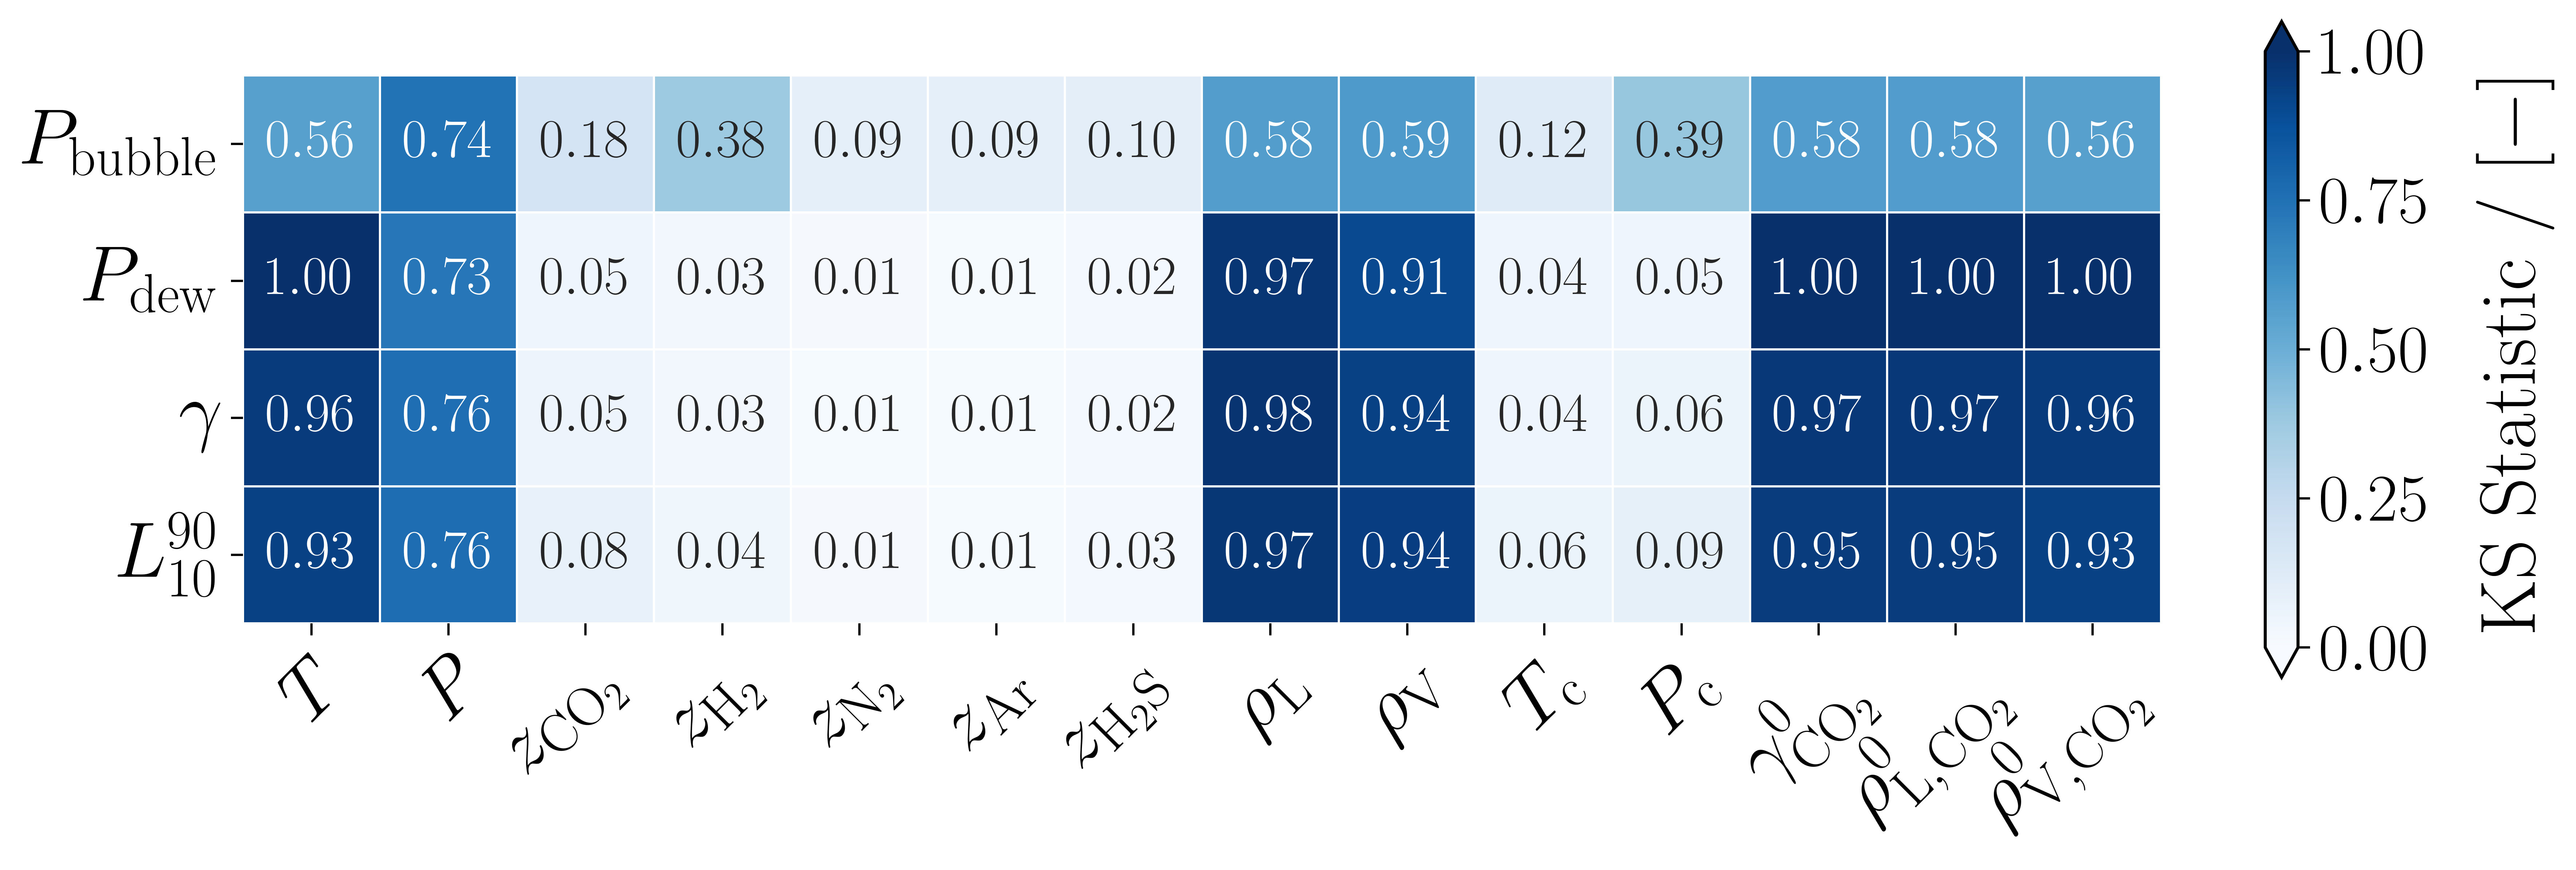

In [4]:
# ── build transposed dataframe: rows=targets, cols=features ──────────────
ks_df  = pd.DataFrame(ks_stat_f, index=feat_labels_f, columns=target_labels).T
ks_ann = ks_df.map(lambda v: rf"${v:.2f}$" if not np.isnan(v) else "")

n_rows, n_cols = ks_df.shape
fig_h = max(4.0, n_rows * CELL_SIZE)
fig_w = max(4.0, n_cols * CELL_SIZE)
fig, ax = ps.plot_init(w=fig_w, h=fig_h)

# ── heatmap ──────────────────────────────────────────────────────────────
cm_ks = sns.heatmap(
    ks_df, ax=ax,
    annot=ks_ann, fmt="",
    cmap="Blues", vmin=0, vmax=1,
    square=True, linewidths=0.5,
    annot_kws={"size": ANNOT_PT},
    cbar_kws={"shrink": CBAR_SHRINK, "fraction": CBAR_FRACTION, "extend": "both"},
)

# ── colorbar ─────────────────────────────────────────────────────────────
cbar_ks = cm_ks.collections[0].colorbar
ps.style_colorbar(cbar_ks)
cbar_ks.ax.tick_params(width=ps.tick_width, length=ps.tick_length, labelsize=TICK_PT)
cbar_ks.set_label(r"$\mathrm{KS \; Statistic}$ / $[-]$", fontsize=LABEL_PT, labelpad=15)
cbar_ks.outline.set_linewidth(1.0)
cbar_ks.ax.yaxis.set_major_formatter(_math_fmt)

# ── axes style ───────────────────────────────────────────────────────────
ps.apply_axis_style(ax)

ax.tick_params(axis="x", which="both", direction="out",
               length=ps.tick_length, width=ps.tick_width, labelsize=TICK_PT,
               bottom=True, top=False, labelbottom=True, labeltop=False)
ax.tick_params(axis="y", which="both", direction="out",
               length=ps.tick_length, width=ps.tick_width, labelsize=TICK_PT,
               left=True, right=False, labelleft=True, labelright=False)

ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_yticks(np.arange(n_rows) + 0.5)

ax.set_xticklabels(ks_df.columns.tolist(), fontsize=LABEL_PT, rotation=45,
                   ha="right", rotation_mode="anchor")
ax.set_yticklabels(ks_df.index.tolist(), fontsize=LABEL_PT, rotation=0)

plt.tight_layout()
ps.save_plot(fig, "ks_statistic")
plt.show()